# Домашние мини-упражнения: токенайзеры, размеры тензоров и attention

В этом ноутбуке собраны решения по всем 5 пунктам мини-ДЗ:

1. дополнительный токенайзер и сравнение на русском и на коде;
2. ручная выписка размеров `Q`, `K`, `V` и `QK^T`;
3. ещё одна модель из `transformers` и её особенности attention;
4. конкретный параметр, соответствующий `W_K`;
5. пример attention-head с интересным паттерном и словесным описанием.


In [1]:
# Если библиотек не хватает, раскомментируйте:
# !pip install -q transformers sentencepiece protobuf matplotlib

import matplotlib.pyplot as plt
import torch
from transformers import AutoConfig, AutoModel, AutoTokenizer

## 1. Ещё один токенайзер: `google/byt5-small`

В качестве **ещё одного** токенайзера я взяла `google/byt5-small`.

Тут `ByT5` работает **на уровне байтов**, а не привычных подслов. Поэтому особенно хорошо видно различие между русским текстом и кодом.


In [2]:
texts = {
    "russian": "Маленькая собака спит на коврике.",
    "code": "def attention(q, k, v):\n    return softmax(q @ k.T) @ v",
}

tokenizer_names = {
    "bert-base-uncased": "BERT WordPiece",
    "gpt2": "GPT-2 byte-level BPE",
    "google/mt5-small": "mT5 SentencePiece",
    "xlm-roberta-base": "XLM-R SentencePiece",
    "google/byt5-small": "ByT5 byte-level tokenizer",
}

rows = []
byt5_samples = {}

for tok_name, tok_descr in tokenizer_names.items():
    tok = AutoTokenizer.from_pretrained(tok_name)
    row = {"tokenizer": tok_descr, "hf_name": tok_name}

    for label, text in texts.items():
        ids = tok(text)["input_ids"]
        tokens = tok.convert_ids_to_tokens(ids)
        row[label] = len(tokens)

        if tok_name == "google/byt5-small":
            byt5_samples[label] = [repr(t) for t in tokens[:25]]

    rows.append(row)

for row in rows:
    print(row)

print("\nПервые токены ByT5:")
for label, sample in byt5_samples.items():
    print(label, sample)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/698 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

{'tokenizer': 'BERT WordPiece', 'hf_name': 'bert-base-uncased', 'russian': 28, 'code': 24}
{'tokenizer': 'GPT-2 byte-level BPE', 'hf_name': 'gpt2', 'russian': 35, 'code': 25}
{'tokenizer': 'mT5 SentencePiece', 'hf_name': 'google/mt5-small', 'russian': 13, 'code': 23}
{'tokenizer': 'XLM-R SentencePiece', 'hf_name': 'xlm-roberta-base', 'russian': 14, 'code': 24}
{'tokenizer': 'ByT5 byte-level tokenizer', 'hf_name': 'google/byt5-small', 'russian': 62, 'code': 56}

Первые токены ByT5:
russian ["'Ð'", "'\\x9c'", "'Ð'", "'°'", "'Ð'", "'»'", "'Ð'", "'µ'", "'Ð'", "'½'", "'Ñ'", "'\\x8c'", "'Ð'", "'º'", "'Ð'", "'°'", "'Ñ'", "'\\x8f'", "' '", "'Ñ'", "'\\x81'", "'Ð'", "'¾'", "'Ð'", "'±'"]
code ["'d'", "'e'", "'f'", "' '", "'a'", "'t'", "'t'", "'e'", "'n'", "'t'", "'i'", "'o'", "'n'", "'('", "'q'", "','", "' '", "'k'", "','", "' '", "'v'", "')'", "':'", "'\\n'", "' '"]


**Что получилось по числу токенов**

| Токенайзер | Русский | Код |
| --- | ---: | ---: |
| `bert-base-uncased` | 28 | 24 |
| `gpt2` | 35 | 25 |
| `google/mt5-small` | 13 | 23 |
| `xlm-roberta-base` | 14 | 24 |
| `google/byt5-small` | 62 | 56 |

**Короткий вывод**

- `ByT5` разбивает строку почти до уровня отдельных байтов, поэтому токенов очень много.
- Для русского текста это особенно заметно: кириллица в UTF-8 кодируется несколькими байтами, поэтому `62` токена против `56` на коде.
- `mT5` и `XLM-R` заметно компактнее на русском, потому что они мультиязычные и лучше покрывают кириллицу.
- `bert-base-uncased` и `gpt2` хуже подходят для русского: текст дробится сильнее.


## 2. Размеры `Q`, `K`, `V` и `QK^T`

Возьмём те же значения, что и в семинаре:

- `B = 2`
- `T = 7`
- `d_model = 768`
- `h = 12`


In [3]:
B = 4
T = 10
d_model = 512
h = 8
d_k = d_model // h

print("X:", (B, T, d_model))
print("Q, K, V до разбиения на головы:", (B, T, d_model))
print("Q, K, V после разбиения на головы:", (B, h, T, d_k))
print("QK^T:", (B, h, T, T))

X: (4, 10, 512)
Q, K, V до разбиения на головы: (4, 10, 512)
Q, K, V после разбиения на головы: (4, 8, 10, 64)
QK^T: (4, 8, 10, 10)


**Ручной ответ**

`d_k = d_model / h = 512 / 8 = 64`.

Тогда:

- после линейных проекций `Q`, `K`, `V` имеют размер `(B, T, d_model) = (4, 10, 512)`;
- после разбиения на головы удобно писать размер как `(B, h, T, d_k) = (4, 8, 10, 64)`;
- произведение `QK^T` считается по последней размерности `d_k`, поэтому его размер равен `(B, h, T, T) = (4, 8, 10, 10)`.

## 3. Ещё одна модель из `transformers`: `google/bigbird-roberta-base`

Для этого пункта я взяла `BigBird`, потому что у неё attention устроен интереснее, чем обычный полный self-attention.


In [4]:
model_name = "google/bigbird-roberta-base"
cfg = AutoConfig.from_pretrained(model_name)

print("model_name:", model_name)
print("hidden_size:", cfg.hidden_size)
print("num_attention_heads:", cfg.num_attention_heads)
print("num_hidden_layers:", cfg.num_hidden_layers)
print("attention_type:", cfg.attention_type)
print("block_size:", cfg.block_size)
print("num_random_blocks:", cfg.num_random_blocks)

config.json:   0%|          | 0.00/760 [00:00<?, ?B/s]

model_name: google/bigbird-roberta-base
hidden_size: 768
num_attention_heads: 12
num_hidden_layers: 12
attention_type: block_sparse
block_size: 64
num_random_blocks: 3


**Ответ**

У `google/bigbird-roberta-base`:

- число слоёв: `12`
- число голов: `12`
- размерность скрытого состояния: `768`

**Интересная особенность attention**

У `BigBird` attention не полный, а `block_sparse`. Это значит:

- есть локальные связи внутри соседних блоков;
- есть несколько случайных блоков (`num_random_blocks = 3`);
- есть глобальные токены, через которые модель может передавать дальний контекст.

Идея в том, чтобы работать с длинными последовательностями дешевле, чем полный attention на все пары токенов.


## 4. Конкретный параметр, который соответствует `W_K`

Для поиска `W_K` удобно взять понятную и более лёгкую архитектуру `DistilBERT`. Здесь для разнообразия возьмём `GPT-2`, у которой проекции Q, K, V объединены в один линейный слой `c_attn`.


In [6]:
model_name = "gpt2"
cfg = AutoConfig.from_pretrained(model_name)
model = AutoModel.from_config(cfg)

# В GPT-2 Q, K, V объединены в один линейный слой c_attn.
# Посмотрим его форму и вычленим, где именно лежит W_K.

for name, param in model.named_parameters():
    if "attn.c_attn" in name and "weight" in name:
        print(name, tuple(param.shape))
        break

# Покажем, как вырезать W_K
c_attn_weight = model.h[0].attn.c_attn.weight
d_model = cfg.n_embd  # 768
W_Q = c_attn_weight[:, :d_model]
W_K = c_attn_weight[:, d_model : 2 * d_model]
W_V = c_attn_weight[:, 2 * d_model :]

print(f"\nc_attn.weight: {tuple(c_attn_weight.shape)}")
print(f"W_Q:           {tuple(W_Q.shape)}")
print(f"W_K:           {tuple(W_K.shape)}")
print(f"W_V:           {tuple(W_V.shape)}")

del model

h.0.attn.c_attn.weight (768, 2304)

c_attn.weight: (768, 2304)
W_Q:           (768, 768)
W_K:           (768, 768)
W_V:           (768, 768)


**Ответ**

В `GPT-2` все три проекции Q, K, V хранятся в одном слое:

`transformer.h.0.attn.c_attn.weight` с формой `(768, 2304)`.

Здесь `2304 = 3 × 768`. Матрица разбивается по столбцам на три блока по 768:

- `[:, :768]` — `W_Q`;
- `[:, 768:1536]` — `W_K`;
- `[:, 1536:2304]` — `W_V`.

То есть `W_K` — это срез `c_attn.weight[:, 768:1536]` формы `(768, 768)`.

Это отличается от `DistilBERT`, где Q, K, V хранятся в отдельных слоях (`q_lin`, `k_lin`, `v_lin`). В `GPT-2` они объединены ради эффективности одного матричного умножения.

## 5. Голова attention с интересным паттерном

Здесь уже лучше смотреть не случайно инициализированную модель, а предобученную. Возьмём `distilbert-base-uncased` и короткое предложение с повтором структуры.


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_transform.bias    | UNEXPECTED |  | 
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


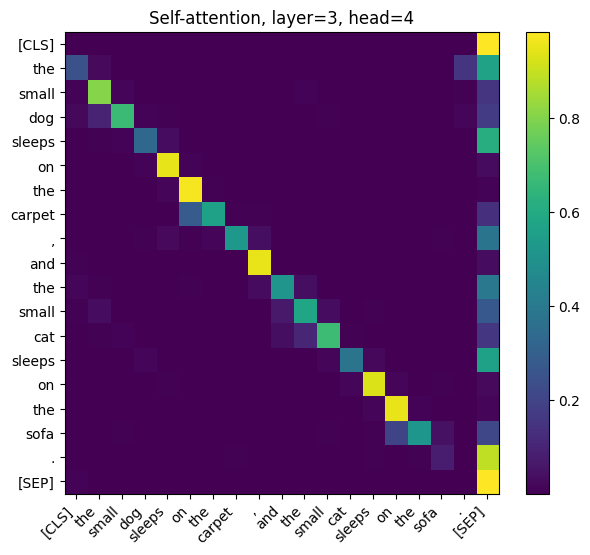

In [7]:
model_name = "distilbert-base-uncased"
tok = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name, attn_implementation="eager")
model.eval()

text = "The small dog sleeps on the carpet, and the small cat sleeps on the sofa."
batch = tok(text, return_tensors="pt")

with torch.no_grad():
    out = model(**batch, output_attentions=True, return_dict=True)

tokens = tok.convert_ids_to_tokens(batch["input_ids"][0])

layer = 3
head = 4
attn = out.attentions[layer][0, head].cpu().numpy()

plt.figure(figsize=(7, 6))
plt.imshow(attn, aspect="auto")
plt.xticks(range(len(tokens)), tokens, rotation=45, ha="right")
plt.yticks(range(len(tokens)), tokens)
plt.title(f"Self-attention, layer={layer}, head={head}")
plt.colorbar()
plt.show()


In [8]:
for i, token in enumerate(tokens):
    top_values, top_idx = torch.topk(out.attentions[layer][0, head, i], k=3)
    top_items = [(tokens[j], round(v.item(), 3)) for v, j in zip(top_values, top_idx)]
    print(f"{i:02d} {token:>8} -> {top_items}")


00    [CLS] -> [('[SEP]', 0.983), ('the', 0.002), ('[CLS]', 0.002)]
01      the -> [('[SEP]', 0.566), ('[CLS]', 0.245), ('.', 0.153)]
02    small -> [('the', 0.804), ('[SEP]', 0.149), ('small', 0.013)]
03      dog -> [('small', 0.668), ('[SEP]', 0.174), ('the', 0.092)]
04   sleeps -> [('[SEP]', 0.613), ('dog', 0.33), ('sleeps', 0.031)]
05       on -> [('sleeps', 0.947), ('[SEP]', 0.028), ('on', 0.011)]
06      the -> [('on', 0.97), ('sleeps', 0.012), ('[SEP]', 0.009)]
07   carpet -> [('the', 0.563), ('on', 0.282), ('[SEP]', 0.135)]
08        , -> [('carpet', 0.525), ('[SEP]', 0.378), (',', 0.035)]
09      and -> [(',', 0.952), ('[SEP]', 0.034), ('[CLS]', 0.005)]
10      the -> [('and', 0.512), ('[SEP]', 0.393), ('the', 0.037)]
11    small -> [('the', 0.581), ('[SEP]', 0.27), ('and', 0.068)]
12      cat -> [('small', 0.673), ('[SEP]', 0.154), ('the', 0.105)]
13   sleeps -> [('[SEP]', 0.564), ('cat', 0.377), ('sleeps', 0.023)]
14       on -> [('sleeps', 0.929), ('[SEP]', 0.026), ('cat', 

**Мой выбор:** `layer = 3`, `head = 4` (нумерация с нуля).

**Почему эта голова интересна**

Она ведёт себя почти как **голова предыдущего токена**:

- `on` очень сильно смотрит на `sleeps`;
- следующий `the` смотрит на `on`;
- `cat` смотрит на `small`;
- `and` почти полностью смотрит на запятую.

При этом часть служебных токенов заметно стягивается к `[SEP]`.

**Описание словами**

Эта голова хорошо отслеживает **локальный левый контекст и границы фразы**. То есть она помогает модели быстро понимать ближайшую синтаксическую структуру: кто стоит перед кем, где заканчивается кусок фразы и где начинается следующий.